<a href="https://colab.research.google.com/github/aspurser84-dot/BIFX546-project/blob/main/notebooks/Final_BIFX546_Project_Graham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Title: COVID-19 Variant tracking in California between 2021 through 2023

##Author: Amanda Graham

###Course: BIFX 546 — Machine Learning for Bioinformatics, Spring 2026

###Instructor: Dr. Sarangan (Ravi) Ravichandran

Date: 3/18/26

Disclaimer: This notebook was created as a final project for class. It uses a publically available dataset, key concepts from BIFX 546 Machine Learning for Bioinformatics and concepts from the textbook Data Sciencefrom Scratch.

#Dataset name: COVID-19 Variant Data

The dataset is publically available from the KaggleHub repository and contains COVID-19 variant data collected including date, area (California), area type (state), variant name, number of specimens collected, percentage of specimens collected, specimens 7 day average and the percentage 7 day average

###Source/URL: https://www.kaggle.com/datasets/nidzsharma/covid-19-variant-data

#Project Goal

###Can we predict the next circulating variant of COVID-19 based on a selection of features?

We hypothesize that there is typically one predominant circlulating variant of COVID-19 during a timeframe. Using a set of features such as the number of specimens collected, the percentage of specimens collected and the change in variant specimens collected per day we can predict the next predominant circulating variant.


#Setting up directory

The below code changes the working directory so the data can be properly saved in Colab.

In [10]:
import os

# Show current working directory
print("Old directory:", os.getcwd())

# Move up one directory
os.chdir("/")

print("New directory:", os.getcwd())

Old directory: /
New directory: /


#Upload the data
There are two options to upload the dataset into colab

1. Download the CSV file from the GitHub repository and upload it with the code below into CoLab:

In [11]:
from google.colab import files
uploaded = files.upload()

2. Import the dataset from Kagglehub repository. This requires an API key setup in CoLab.

In [12]:
#Imports the dataset from Kagglehub repository and
#places the dataset in kaggle/input/ folder
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nidzsharma/covid-19-variant-data")

# Verify the actual data file is present, if not force re-download
csv_file = os.path.join(path, "covid19_variant.csv")

if not os.path.exists(csv_file):
  path = kagglehub.dataset_download("nidzsharma/covid-19-variant-data", force_download=True)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'covid-19-variant-data' dataset.
Path to dataset files: /kaggle/input/covid-19-variant-data


#Data overview

The below code converts the downloaded csv file to a pandas dataframe. Then a quick summary is created for the following variables; specimens, percentage, specimens 7 day average, and percentage 7 day average, to calculate count, average, standard deviation, minimum, quantiles, and the maximum.

This is important since we can see the number of specimens collected and percentage of specimens collected does not match the specimens 7 day average or percentage 7 day average. The specimens 7 day average and percentage 7 day average have missing values that will need to be calculated.

In [13]:
#converts csv file to pandas dataframe
import pandas as pd

#quick summary of dataset
df = pd.read_csv(csv_file)
df.describe()

,specimens,percentage,specimens_7d_avg,percentage_7d_avg
count,7790.000000,7790.000000,7730.000000,7730.000000
mean,177.596919,20.000004,178.622731,20.000000
std,485.649656,37.925758,449.876303,37.927537
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.142857,0.013672
75%,28.000000,7.380000,27.857143,7.414083
max,5802.000000,100.000000,3295.000000,100.000000


The below code provides value counts for the number of variants.

This is important and shows there is also a total and other count being calculated. These both will need to be removed when comparing individual variants.

In [14]:
#Determine the number of variants
#pd.value_counts(df["variant_name"])
pd.Series(df["variant_name"]).value_counts()

,count
variant_name,
Alpha,779
Lambda,779
Other,779
Epsilon,779
Omicron,779
Beta,779
Total,779
Delta,779
Mu,779


The below code calculates summary statistics median, average and standard deviation for each variant. Here we can already see there are two variants that have a higher presence in the data. Delta and Omicron.

We can also confirm the Total variant is the combined value for all variants and this will need to be removed when comparing the different variants.

In [15]:
#summary stats median, mean and standard deviation by variant type
df.groupby("variant_name")["specimens"].agg(["median", "mean", "std"])

,median,mean,std
variant_name,,,
Alpha,0.0,21.079589,48.532144
Beta,0.0,0.218228,0.868546
Delta,0.0,310.150193,654.710835
Epsilon,0.0,31.997433,98.848317
Gamma,0.0,4.747112,10.588784
Lambda,0.0,0.227214,0.855034
Mu,0.0,1.471117,5.580458
Omicron,241.0,491.812580,706.144161
Other,5.0,26.281130,55.751669


The below code determines if there are any NA values.

We can see the specimens 7 day average and percentage 7 day average do have missing values. These will need to be calculated and filled in.

In [16]:
#Determine if there are any NA values
df.isna().sum()
#Since the NA values are in 7day avg no need to remove these rows without 7 day averages

,0
date,0
area,0
area_type,0
variant_name,0
specimens,0
percentage,0
specimens_7d_avg,60
percentage_7d_avg,60


The below code determines what data type each variable is. We can see date is an object but this is incorrect and we will need to change this to a date data type.

In [17]:
df.dtypes

,0
date,object
area,object
area_type,object
variant_name,object
specimens,int64
percentage,float64
specimens_7d_avg,float64
percentage_7d_avg,float64


The below code determines how many values are listed in the variable area. We can see there is only one value for area, California, which is not meaningful. This variable will have to be removed.

In [18]:
pd.Series(df["area"]).value_counts()

,count
area,
California,7790


The below code determines how many values are listed in the variable area_type. We can see there is only one value for area_type, State, which is not meaningful. This variable will have to be removed.

In [19]:
pd.Series(df["area_type"]).value_counts()

,count
area_type,
State,7790


#Data Cleaning

The below code changes the date variable to a date time data type.

This will allow us to properly sort the data by date and graph the data in seaborn.

In [20]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df.dtypes

,0
date,datetime64[ns]
area,object
area_type,object
variant_name,object
specimens,int64
percentage,float64
specimens_7d_avg,float64
percentage_7d_avg,float64


The code below removes the unnecessary columns area and area_type, as these only contain one value and are not meaningful.

In [21]:
df1 = df.copy()
df1 = df1.drop(columns=['area', 'area_type'])
df1.dtypes

,0
date,datetime64[ns]
variant_name,object
specimens,int64
percentage,float64
specimens_7d_avg,float64
percentage_7d_avg,float64


The below code sorts the dataframe by date and variant name. This is important so we can verify the 7 day average calculations.

In [22]:
#sort data by variant and date

#sort by variant
df1 = df1.sort_values(by= ['variant_name',"date"], ascending=True)
df1

,date,variant_name,specimens,percentage,specimens_7d_avg,percentage_7d_avg
0,2021-01-01,Alpha,1,1.69,NaN,NaN
10,2021-01-02,Alpha,6,5.56,NaN,NaN
20,2021-01-03,Alpha,5,1.87,NaN,NaN
31,2021-01-04,Alpha,5,0.40,NaN,NaN
42,2021-01-05,Alpha,16,1.97,NaN,NaN
...,...,...,...,...,...,...
7747,2023-02-14,Total,87,100.00,118.285714,100.0
7754,2023-02-15,Total,176,100.00,115.857143,100.0
7760,2023-02-16,Total,148,100.00,110.142857,100.0
7773,2023-02-17,Total,40,100.00,95.142857,100.0


The below code calculates the rolling 7 day average for both specimens and percentage. It is important to sort the dataframe by variant and date before calculating these averages to get a correct 7 day average.

In [23]:
# Calculate 7-day rolling average
#specimens_7d_avg
data_sorted = df1.sort_values(by= ['variant_name',"date"], ascending=True)
series_specimen = pd.Series(data_sorted['specimens'])

moving_avg_specimens = series_specimen.rolling(window=7).mean()

#percentage_7d_avg
data = df1['percentage'].tolist()
series_percentage = pd.Series(data_sorted['percentage'])

moving_avg_percentage = series_percentage.rolling(window=7).mean()

The below code filles in the NA values with the calculated rolling 7 day average for both specimens and percentage.

However the first 6 days cannot calculate a 7 day average and these must be filled in with a values of zero using .fillna(0).

In [24]:
#Instead we want to fill in N/A values with 7 day average

df2 = df1.copy()
df2['specimens_7d_avg'] = moving_avg_specimens
df2['percentage_7d_avg'] = moving_avg_percentage

df2['specimens_7d_avg'] = df2['specimens_7d_avg'].fillna(0)
df2['percentage_7d_avg'] = df2['percentage_7d_avg'].fillna(0)

print(df2.head(14))

          date variant_name  specimens  percentage  specimens_7d_avg  \
0   2021-01-01        Alpha          1        1.69          0.000000   
10  2021-01-02        Alpha          6        5.56          0.000000   
20  2021-01-03        Alpha          5        1.87          0.000000   
31  2021-01-04        Alpha          5        0.40          0.000000   
42  2021-01-05        Alpha         16        1.97          0.000000   
50  2021-01-06        Alpha          3        0.81          0.000000   
67  2021-01-07        Alpha         15        5.02          7.285714   
72  2021-01-08        Alpha          2        1.34          7.428571   
82  2021-01-09        Alpha          6        1.12          7.428571   
96  2021-01-10        Alpha          0        0.00          6.714286   
104 2021-01-11        Alpha          8        1.41          7.142857   
112 2021-01-12        Alpha          9        1.62          6.142857   
124 2021-01-13        Alpha          9        1.55          7.00

This code confirms all NA values are filled in.

In [25]:
#Verify NA values were filled in
df2.isna().sum()

,0
date,0
variant_name,0
specimens,0
percentage,0
specimens_7d_avg,0
percentage_7d_avg,0


The below code removes all rows with Total and Other as the variant name. This is redundant information or is not meaningful.

In [26]:
#Need to remove all rows with "Total" in variant_name
A_value_to_remove = 'Total'
B_value_to_remove = 'Other'

# Remove rows where 'variant_name' equals "Total"
df2 = df2[df2['variant_name'] != A_value_to_remove]
df2 = df2[df2['variant_name'] != B_value_to_remove]

pd.Series(df2["variant_name"]).value_counts()

,count
variant_name,
Alpha,779
Beta,779
Delta,779
Epsilon,779
Gamma,779
Lambda,779
Mu,779
Omicron,779


The below code calculates the rate in change for number of specimens per day by variant. It is important to group the data by variant name so the change can be properly calculated. It also fills in the first value of rate change with zero since this can't be calculated.

In [27]:
#calculates the rate change for number of specimens per day
#Also fills in the N/A values with zero
rate_change = df2.groupby('variant_name', as_index=False)['specimens'].diff()

df3 = df2.copy()
df3['rate_change'] = rate_change

df3['rate_change'] = df3['rate_change'].fillna(0)

df3.head(14)


,date,variant_name,specimens,percentage,specimens_7d_avg,percentage_7d_avg,rate_change
0,2021-01-01,Alpha,1,1.69,0.000000,0.000000,0.0
10,2021-01-02,Alpha,6,5.56,0.000000,0.000000,5.0
20,2021-01-03,Alpha,5,1.87,0.000000,0.000000,-1.0
31,2021-01-04,Alpha,5,0.40,0.000000,0.000000,0.0
42,2021-01-05,Alpha,16,1.97,0.000000,0.000000,11.0
50,2021-01-06,Alpha,3,0.81,0.000000,0.000000,-13.0
67,2021-01-07,Alpha,15,5.02,7.285714,2.474286,12.0
72,2021-01-08,Alpha,2,1.34,7.428571,2.424286,-13.0
82,2021-01-09,Alpha,6,1.12,7.428571,1.790000,4.0
96,2021-01-10,Alpha,0,0.00,6.714286,1.522857,-6.0


The below code calculates the 7 day average for rate change and fills in the first 6 values with zero. It is important to sort the dataframe by variant and date before calculating these averages to get a correct 7 day average.

In [28]:
# Calculate 7-day rolling average
#rate change

data_sorted2 = df3.sort_values(by= ['variant_name',"date"], ascending=True)
series_rate = pd.Series(data_sorted2['rate_change'])

moving_avg_rate = series_rate.rolling(window=7).mean()

df3['rate_change_7d_avg'] = moving_avg_rate

df3['rate_change_7d_avg'] = df3['rate_change_7d_avg'].fillna(0)
print(df3.head(14))

          date variant_name  specimens  percentage  specimens_7d_avg  \
0   2021-01-01        Alpha          1        1.69          0.000000   
10  2021-01-02        Alpha          6        5.56          0.000000   
20  2021-01-03        Alpha          5        1.87          0.000000   
31  2021-01-04        Alpha          5        0.40          0.000000   
42  2021-01-05        Alpha         16        1.97          0.000000   
50  2021-01-06        Alpha          3        0.81          0.000000   
67  2021-01-07        Alpha         15        5.02          7.285714   
72  2021-01-08        Alpha          2        1.34          7.428571   
82  2021-01-09        Alpha          6        1.12          7.428571   
96  2021-01-10        Alpha          0        0.00          6.714286   
104 2021-01-11        Alpha          8        1.41          7.142857   
112 2021-01-12        Alpha          9        1.62          6.142857   
124 2021-01-13        Alpha          9        1.55          7.00

#Data Visualization

The below code creates a file path to export the following images.

In [29]:
# File path (can include folders)
file_path = "output/data.csv"

try:
    # Ensure the directory exists
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    # Export DataFrame to CSV
    df3.to_csv(file_path, index=False, encoding="utf-8")

    print(f"DataFrame successfully exported to '{file_path}'")
except PermissionError:
    print("Error: Permission denied. Please check file permissions.")
except FileNotFoundError:
    print("Error: Invalid file path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

DataFrame successfully exported to 'output/data.csv'


##Distribution of Variants

The below code creates a box plot for the number of specimens collected per variant.

Here we can see there are two variants with a higher number of specimens present, Delta and Omicron.

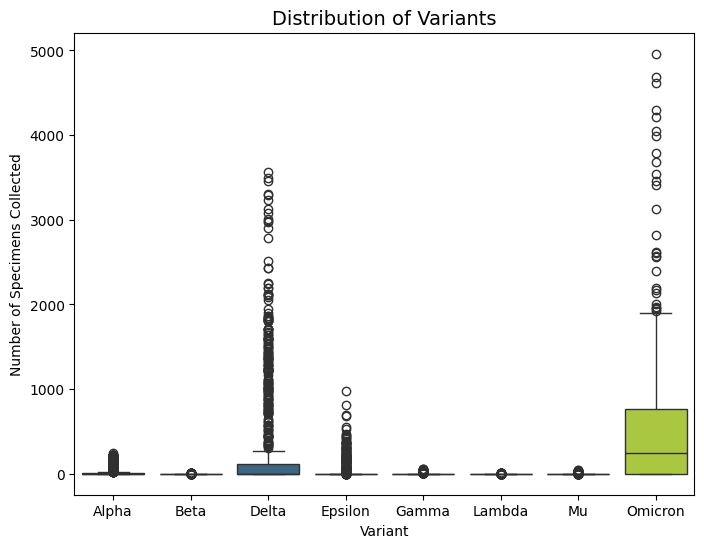

In [30]:
#Boxplot of number of specimen collected per variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
box_plot = sns.boxplot(
    data=df3,
    x="variant_name",
    y="specimens",
    hue="variant_name",   # Color by category
    palette="viridis",    # Color palette
    legend=False
)

# Add labels and title
plt.title("Distribution of Variants", fontsize=14)
plt.xlabel("Variant")
plt.ylabel("Number of Specimens Collected")

# Display plot
plt.show()

#save as png
fig = box_plot.get_figure()
fig.savefig('output/Distribution_of_Variants.png')

##Number of Specimens Collected Over Time by Variant

The code below graphs the number of specimens collected over time by variant. We can see the variant Delta starts about 07/2021 and is the main variant present until about 01/2022. Then both variants are present for a short time until the variant Omicron is the main variant until about 01/2023. Most of the other variants are present in low abundance.

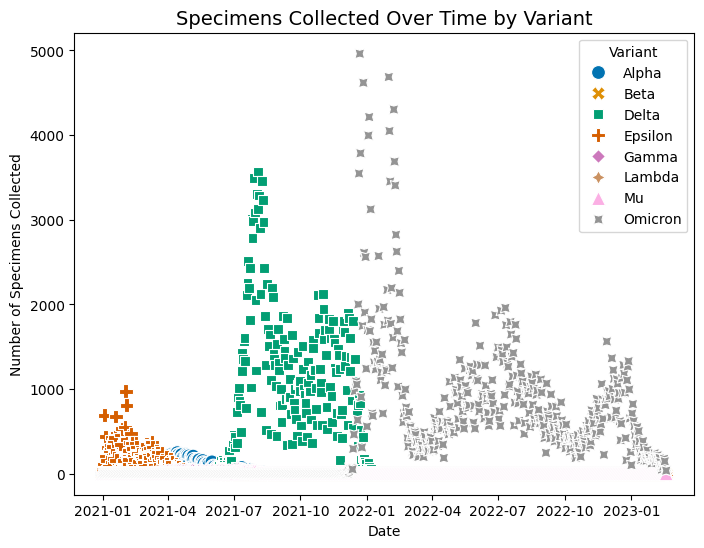

In [31]:
#XY scatter plot specimens collected over time by variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
count_plot = sns.scatterplot(
    data=df3,
    x= "date",
    y="specimens",
    hue="variant_name",   # Color by category
    style="variant_name", # Different marker styles
    s=100,            # Marker size
    palette="colorblind"    # Color palette
)

# Add labels and title
plt.title("Specimens Collected Over Time by Variant", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Specimens Collected")
plt.legend(title="Variant")

# Display plot
plt.show()

#save as png
fig = count_plot.get_figure()
fig.savefig('output/Specimens_Collected_Over_Time.png')

##Percentage of Variants Over Time
The below code graphs the percentage of variants over time.

This graph better shows the low abundance variants as a mixed population between 01/2021 through 07/2021. Between 01/2021 and 04/2021 we can see Epsilon and Other variant being the predominant variants present. Then between 04/2021 and 07/2021 we can see Alpha is the predominant variant present with the other variants still present in low abundance. Then we can see as Delta decreases in predominance Omicron increases and becomes the predominant variant present.

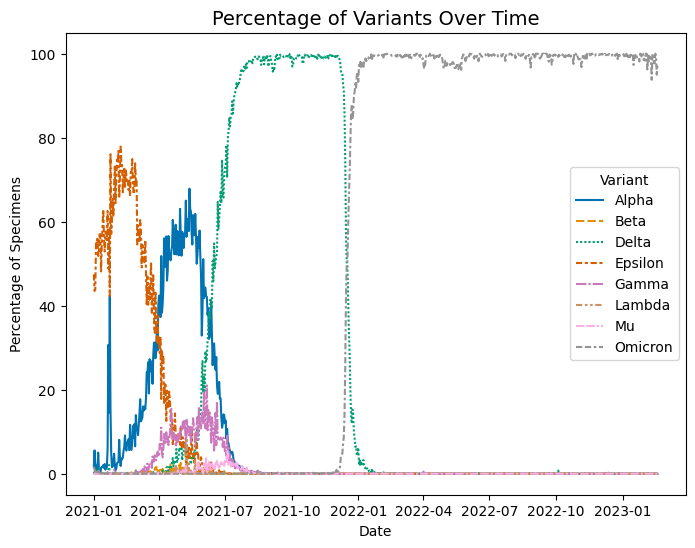

In [32]:
#line plot percentage collected over time by variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
percentage_plot = sns.lineplot(
    data=df3,
    x="date",
    y="percentage",
    hue="variant_name",   # Color by category
    style="variant_name", # Different marker styles
    #s=100,            # Marker size
    palette="colorblind"    # Color palette
)

# Add labels and title
plt.title("Percentage of Variants Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Percentage of Specimens")
plt.legend(title="Variant")

# Display plot
plt.show()

#save as png
fig = percentage_plot.get_figure()
fig.savefig('output/Percentage_Variants_Over_Time.png')

##Rate of Change per Variant

The below code graphs the rate of change per variant over time.

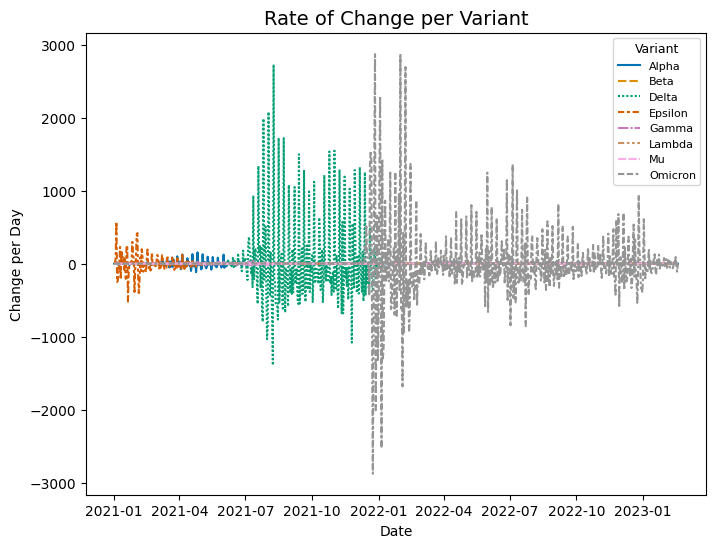

In [33]:
#line plot rate of change by variant

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
change_plot = sns.lineplot(
    data= df3,
    x="date",
    y="rate_change",
    hue="variant_name",   # Color by category
    style="variant_name", # Different marker styles
    palette="colorblind"    # Color palette
)

# Add labels and title
plt.title("Rate of Change per Variant", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Change per Day")
plt.legend(title="Variant", fontsize=8, title_fontsize=9, markerscale=0.7)

# Display plot
plt.show()

#save as png
fig = change_plot.get_figure()
fig.savefig('output/Rate_of_change_per_Variant.png')

##7 Day Rate of Change per Variant

The below code graphs the 7 day rate of change per variant over time.

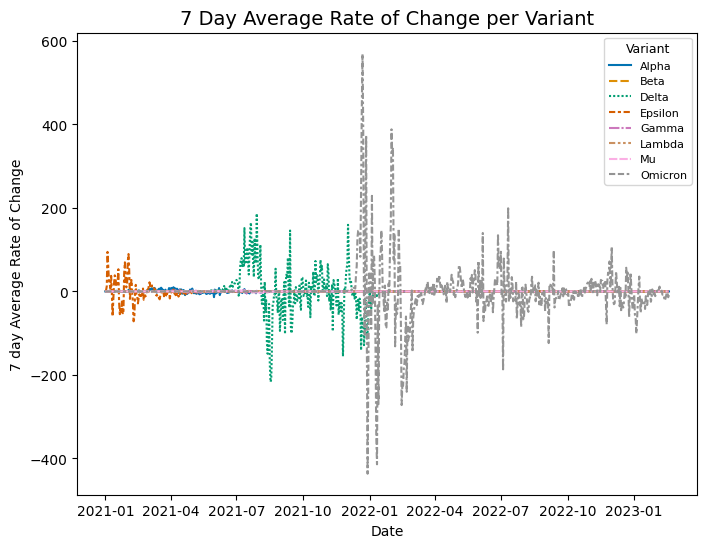

In [47]:
#line plot 7day rate of change by variant

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
change_plot = sns.lineplot(
    data= df3,
    x="date",
    y="rate_change_7d_avg",
    hue="variant_name",   # Color by category
    style="variant_name", # Different marker styles
    palette="colorblind"    # Color palette
)

# Add labels and title
plt.title("7 Day Average Rate of Change per Variant", fontsize=14)
plt.xlabel("Date")
plt.ylabel("7 day Average Rate of Change")
plt.legend(title="Variant", fontsize=8, title_fontsize=9, markerscale=0.7)

# Display plot
plt.show()


# Random Forest Model

The code below loads the necessary packages???

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

The code below encodes variant names to numeric values using a dictionary. This is necessary to properly train the model. These values can then be called back using the dictionary encoder_list to see the variant names predicted.

In [36]:
#encode catagorical values to numeric
#this is needed to preform scalar fit transform
df4 = df3.copy()
encoder_list = df4['variant_name'].unique()
encoder_values = [i for i in range(len(encoder_list))]
encoder_dict = dict(zip(encoder_list, encoder_values))
df4['variant_name'] = df4['variant_name'].map(encoder_dict)
pd.Series(df4["variant_name"]).value_counts()
print(encoder_list, encoder_values)


['Alpha' 'Beta' 'Delta' 'Epsilon' 'Gamma' 'Lambda' 'Mu' 'Omicron'] [0, 1, 2, 3, 4, 5, 6, 7]


In [37]:
df_sorted = df4.sort_values(by='date')

In [38]:
X = df4.drop('variant_name', axis=1)
Y = df4['variant_name']
feature_names = X.columns.tolist()
print(feature_names)

print(f'X shape: {X.shape}')
print(f'Y shape: {Y.shape}')
print(f'Target range: {Y.min():.1f} – {Y.max():.1f}  |  mean: {Y.mean():.1f}')

['date', 'specimens', 'percentage', 'specimens_7d_avg', 'percentage_7d_avg', 'rate_change', 'rate_change_7d_avg']
X shape: (6232, 7)
Y shape: (6232,)
Target range: 0.0 – 7.0  |  mean: 3.5


In [39]:
###DELETE!!!
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=2)

X_tscv = df_sorted.drop('variant_name', axis=1)
y_tscv = df_sorted['variant_name']

for train_idx, test_idx in tscv.split(X_tscv):
    X_train, X_test = X_tscv.iloc[train_idx], X_tscv.iloc[test_idx]
    y_train, y_test = y_tscv.iloc[train_idx], y_tscv.iloc[test_idx]
print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Features     : {X_train.shape[1]}')

Training set : 4155 samples
Test set     : 2077 samples
Features     : 7


In [40]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=2)
for train_idx, test_idx in tscv.split(df_sorted):
    X_train, X_test = df_sorted.iloc[train_idx], df_sorted.iloc[test_idx]
    y_train, y_test = df_sorted.iloc[train_idx], df_sorted.iloc[test_idx]
print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Features     : {X_train.shape[1]}')

Training set : 4155 samples
Test set     : 2077 samples
Features     : 8


In [41]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)
X_train_clean = X_train.drop('date', axis=1)
X_test_clean = X_test.drop('date', axis=1)
y_train_clean = y_train['variant_name']
y_test_clean = y_test['variant_name']

# Fit the model
clf.fit(X_train_clean, y_train_clean)

# Make predictions
y_pred = clf.predict(X_test_clean)

df5 = pd.DataFrame(X_test_clean, columns=feature_names)
df5['date'] = X_test['date']
df5['variant_name'] = y_test['variant_name']
df5['prediction'] = y_pred

print(df5)

           date  specimens  percentage  specimens_7d_avg  percentage_7d_avg  \
5192 2022-06-04          0         0.0          0.000000           0.000000   
5193 2022-06-04        818       100.0       1063.285714          99.117143   
5195 2022-06-04          0         0.0          0.000000           0.000000   
5199 2022-06-04          0         0.0          0.000000           0.000000   
5194 2022-06-04          0         0.0          0.000000           0.000000   
...         ...        ...         ...               ...                ...   
7782 2023-02-18          0         0.0          0.000000           0.000000   
7786 2023-02-18          0         0.0          0.000000           0.000000   
7780 2023-02-18          0         0.0          0.000000           0.000000   
7783 2023-02-18          0         0.0          0.000000           0.000000   
7787 2023-02-18         36        97.3         88.857143          98.167143   

      rate_change  rate_change_7d_avg  variant_name

In [42]:
from sklearn.metrics import classification_report
variant_name = encoder_list
print(classification_report(y_test_clean, y_pred, target_names= variant_name ))

              precision    recall  f1-score   support

       Alpha       1.00      1.00      1.00       260
        Beta       1.00      1.00      1.00       260
       Delta       1.00      0.99      0.99       259
     Epsilon       0.99      1.00      0.99       259
       Gamma       1.00      1.00      1.00       259
      Lambda       1.00      1.00      1.00       260
          Mu       1.00      1.00      1.00       260
     Omicron       1.00      1.00      1.00       260

    accuracy                           1.00      2077
   macro avg       1.00      1.00      1.00      2077
weighted avg       1.00      1.00      1.00      2077



In [43]:
# Re-use the encoded X, y from earlier
rf = RandomForestClassifier(n_estimators=200,
                             criterion='entropy',
                             max_features='sqrt',      # sqrt(p) per split
                             oob_score=True,           # use OOB samples as validation
                             random_state=42)
rf.fit(X_train_clean, y_train_clean)

print(f"RF training accuracy : {rf.score(X_train_clean, y_train_clean):.0%}")
print(f"RF OOB score (≈ test): {rf.oob_score_:.2%}")
print()

# Feature importances
print("Feature importances (Random Forest):")
for name, imp in sorted(zip(feature_names, rf.feature_importances_), key=lambda x: -x[1]):
    bar = '█' * int(imp * 40)
    print(f"  {name:8s}: {imp:.4f}  \n {bar}")

RF training accuracy : 100%
RF OOB score (≈ test): 100.00%

Feature importances (Random Forest):
  date    : 0.8076  
 ████████████████████████████████
  specimens_7d_avg: 0.0580  
 ██
  percentage_7d_avg: 0.0579  
 ██
  specimens: 0.0296  
 █
  percentage: 0.0285  
 █
  rate_change_7d_avg: 0.0106  
 
  rate_change: 0.0077  
 


In [44]:
from sklearn.ensemble import RandomForestClassifier

n_trees_range = [1, 5, 10, 20, 50, 100, 200]

print(f"{'n_estimators':<15} {'OOB Score':>10}")
print('-' * 28)

for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf.fit(X_train_clean, y_train_clean)
    print(f"{n:<15} {rf.oob_score_:>10.0%}")

print()
print('OOB score stabilizes as more trees are added.')
print('This is a free accuracy estimate: no separate test set needed.')

n_estimators     OOB Score
----------------------------
1                      40%
5                      86%
10                     97%
20                     99%


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


50                    100%
100                   100%
200                   100%

OOB score stabilizes as more trees are added.
This is a free accuracy estimate: no separate test set needed.


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


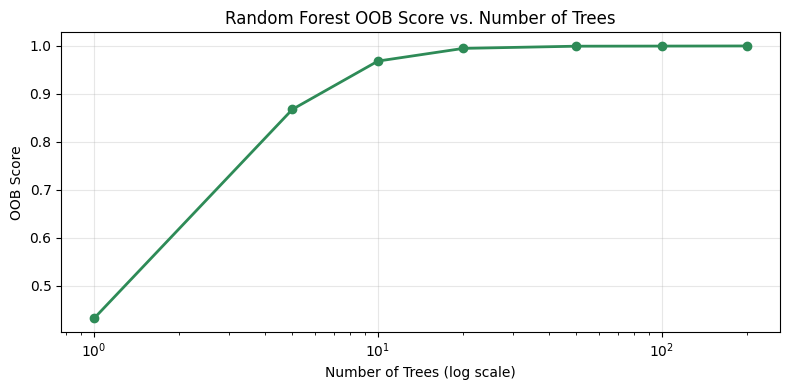

In [45]:
# Show how OOB score improves as we add more trees
n_trees_range = [1, 5, 10, 20, 50, 100, 200]
oob_scores = []

for n in n_trees_range:
    rf_n = RandomForestClassifier(n_estimators=n, criterion='entropy',
                                   oob_score=True, random_state=42)
    rf_n.fit(X_train_clean, y_train_clean)
    oob_scores.append(rf_n.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(n_trees_range, oob_scores, 'o-', color='seagreen', lw=2)
plt.xscale('log')
plt.xlabel('Number of Trees (log scale)')
plt.ylabel('OOB Score')
plt.title('Random Forest OOB Score vs. Number of Trees')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##Results:
During the COVID-19 pandemic it was unknown if variants were present in equal abundance and circulating at the same time. This dataset provides insight on the predominant variant over time. It shows while there are some instances of multiple variants circulating, for the most part one variant becomes the predominant variant for a short period of time. Then as that variant starts to decrease we can see another variant increase and become the predominant variant.

##Challenges:
Uploading the data from the Kagglehub repository to work on Colab was the most challenging as this required additional code to set the correct working directory in Colab. Another challenge was having proper x labels for the seaborn plots. It was discovered the data type was an object and seaborn could not properly automate tick marks. In order to do this, additional code was created to use to_datetime and convert the Date variable into a proper date time data type. Further, I originally graphed the boxplot using matplot to demonstrate using an alternative graphing method but found seaborn is more user friendly, easily graphed the same data and was more appealing.

##Future Steps:
Create a model that can predict whether a variant will be dominant (above a threshold percentage) given its 7-day average and other features.
Requires the data to be separated into a training and validation dataset.
The training dataset would be used to train the model, and the validation dataset would be used to validate the model. Simple Logistic Regression or decision tree would work well for this classification.

In [46]:
#decode catagorical values to numeric
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le = LabelEncoder()
encoded = le.fit_transform(categories)
print("Encoded:", encoded)

decoded = le.inverse_transform(encoded)
print("Decoded:", decoded)

NameError: name 'categories' is not defined

##Linear SVC

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
X = df4.drop('variant_name', axis=1)
y = df4['variant_name']
clf = make_pipeline(StandardScaler(),
                    LinearSVC(random_state=0, tol=1e-5))
clf.fit(X, y)

In [ ]:
print(clf.named_steps['linearsvc'].coef_)
print(clf.named_steps['linearsvc'].intercept_)
print(clf.predict([[0, 0, 0, 0]]))

In [ ]:
clf.score(X, y, sample_weight=None)
